In [1]:
import pandas as pd

In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\HP\OneDrive\Documents\icc-cricket-world-cup-odi.csv")

In [6]:
print(df.head(5))

            date     host     stadium       match_type       team_1  \
0   May 30, 2019  England    The Oval        1st match      England   
1   May 31, 2019  England  Nottingham        2nd match     Pakistan   
2  June 01, 2019  England     Cardiff        3rd match    Sri Lanka   
3  June 01, 2019  England     Bristol  4th match (D/N)  Afghanistan   
4  June 02, 2019  England    The Oval        5th match   Bangladesh   

         team_2 team_1_score team_2_score       winner margin margin_type  \
0  South Africa    311 for 8          207      England    104        runs   
1   West Indies          105    108 for 3  West Indies      7     wickets   
2   New Zealand          136    137 for 0  New Zealand     10     wickets   
3     Australia          207    209 for 3    Australia      7     wickets   
4  South Africa    330 for 6    309 for 8   Bangladesh     21        runs   

          winning_condition                 series season season_winner  
0                       NaN  ICC Cri

In [7]:
print(df.columns.tolist())

['date', 'host', 'stadium', 'match_type', 'team_1', 'team_2', 'team_1_score', 'team_2_score', 'winner', 'margin', 'margin_type', 'winning_condition', 'series', 'season', 'season_winner']


In [9]:
print(df.shape)

(454, 15)


In [11]:
print(df['season'].unique())


['2019' '1979' '1983' '2010/11' '2002/03' '1995/96' '1991/92' '1975'
 '1987/88' '1999' '2014/15' '2006/07']


In [12]:
winners_df = df.dropna(subset=['winner'])

# Count wins by team
wins = winners_df['winner'].value_counts()

print(wins.head(10))

winner
Australia       69
New Zealand     54
India           53
England         48
Pakistan        45
West Indies     43
Sri Lanka       40
South Africa    38
Bangladesh      14
Zimbabwe        12
Name: count, dtype: int64


In [14]:


# Basic information
print(df.info())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               454 non-null    object
 1   host               454 non-null    object
 2   stadium            454 non-null    object
 3   match_type         454 non-null    object
 4   team_1             454 non-null    object
 5   team_2             454 non-null    object
 6   team_1_score       445 non-null    object
 7   team_2_score       440 non-null    object
 8   winner             454 non-null    object
 9   margin             454 non-null    object
 10  margin_type        454 non-null    object
 11  winning_condition  219 non-null    object
 12  series             454 non-null    object
 13  season             454 non-null    object
 14  season_winner      454 non-null    object
dtypes: object(15)
memory usage: 53.3+ KB
None

Missing Values:
date                   0
host   

In [16]:
import pandas as pd
import re

# Make a copy
clean_df = df.copy()

# Remove duplicate rows
clean_df = clean_df.drop_duplicates()

# Standardize team names
clean_df['team_1'] = clean_df['team_1'].str.strip()
clean_df['team_2'] = clean_df['team_2'].str.strip()
clean_df['winner'] = clean_df['winner'].str.strip()

# Fix date ranges such as "June 13 - 15, 1979"
def fix_date(date_str):
    if pd.isna(date_str):
        return date_str

    match = re.match(r'([A-Za-z]+)\s+(\d+)\s*-\s*\d+,\s*(\d{4})', str(date_str))

    if match:
        month, day, year = match.groups()
        return f"{month} {day}, {year}"

    return date_str

clean_df['date'] = clean_df['date'].apply(fix_date)

# Convert date column
clean_df['date'] = pd.to_datetime(clean_df['date'], errors='coerce')

# Check dataframe info and missing values
print(clean_df.info())
print("\nMissing values:")
print(clean_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               454 non-null    datetime64[ns]
 1   host               454 non-null    object        
 2   stadium            454 non-null    object        
 3   match_type         454 non-null    object        
 4   team_1             454 non-null    object        
 5   team_2             454 non-null    object        
 6   team_1_score       445 non-null    object        
 7   team_2_score       440 non-null    object        
 8   winner             454 non-null    object        
 9   margin             454 non-null    object        
 10  margin_type        454 non-null    object        
 11  winning_condition  219 non-null    object        
 12  series             454 non-null    object        
 13  season             454 non-null    object        
 14  season_win

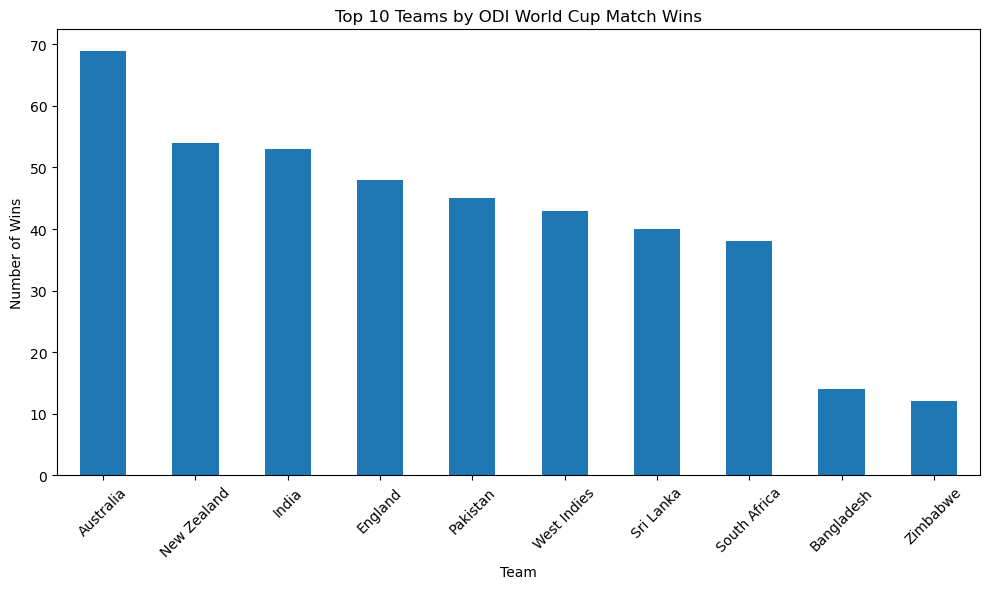

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

wins = clean_df['winner'].value_counts().head(10)

plt.figure(figsize=(10,6))
wins.plot(kind='bar')

plt.title('Top 10 Teams by ODI World Cup Match Wins')
plt.xlabel('Team')
plt.ylabel('Number of Wins')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

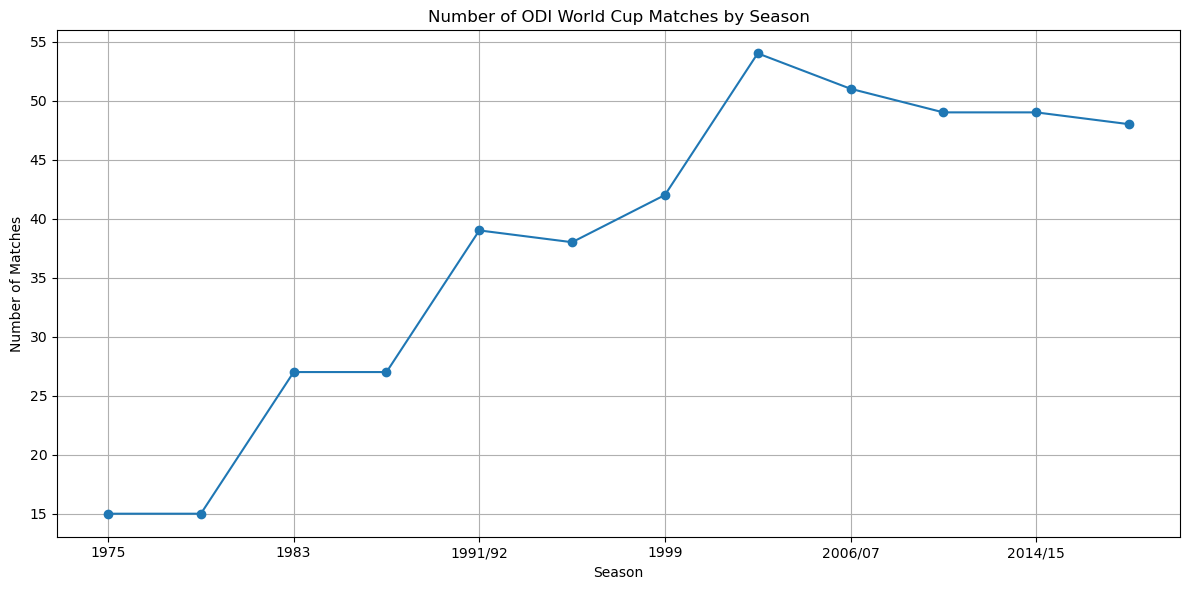

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

matches_per_season = clean_df.groupby('season').size()

plt.figure(figsize=(12,6))
matches_per_season.plot(kind='line', marker='o')

plt.title('Number of ODI World Cup Matches by Season')
plt.xlabel('Season')
plt.ylabel('Number of Matches')

plt.grid(True)
plt.tight_layout()
plt.show()

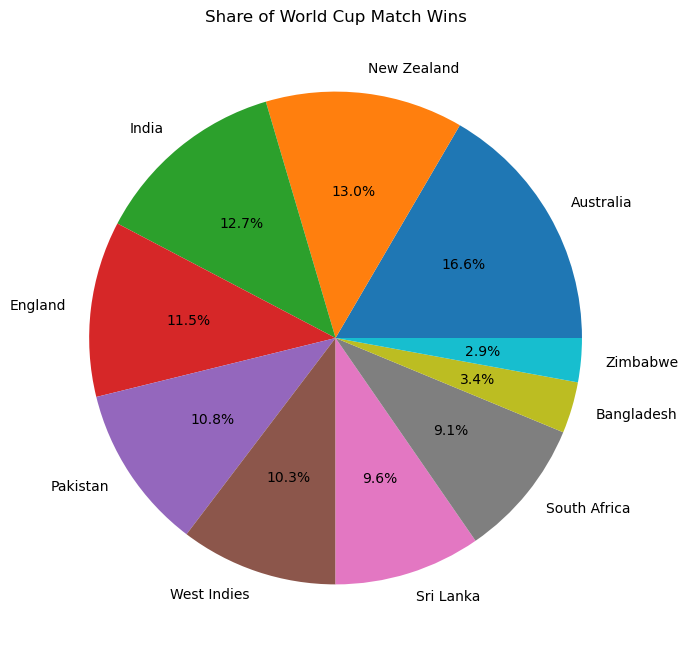

In [21]:
top10 = clean_df['winner'].value_counts().head(10)

plt.figure(figsize=(8,8))
plt.pie(top10, labels=top10.index, autopct='%1.1f%%')

plt.title('Share of World Cup Match Wins')
plt.show()

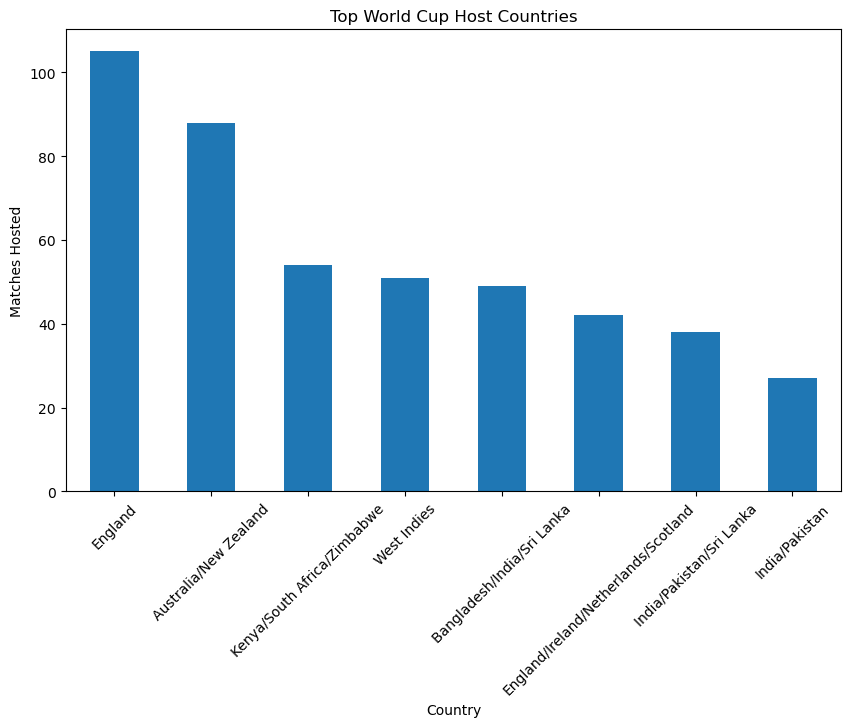

In [22]:
hosts = clean_df['host'].value_counts().head(10)

plt.figure(figsize=(10,6))
hosts.plot(kind='bar')

plt.title('Top World Cup Host Countries')
plt.xlabel('Country')
plt.ylabel('Matches Hosted')

plt.xticks(rotation=45)
plt.show()

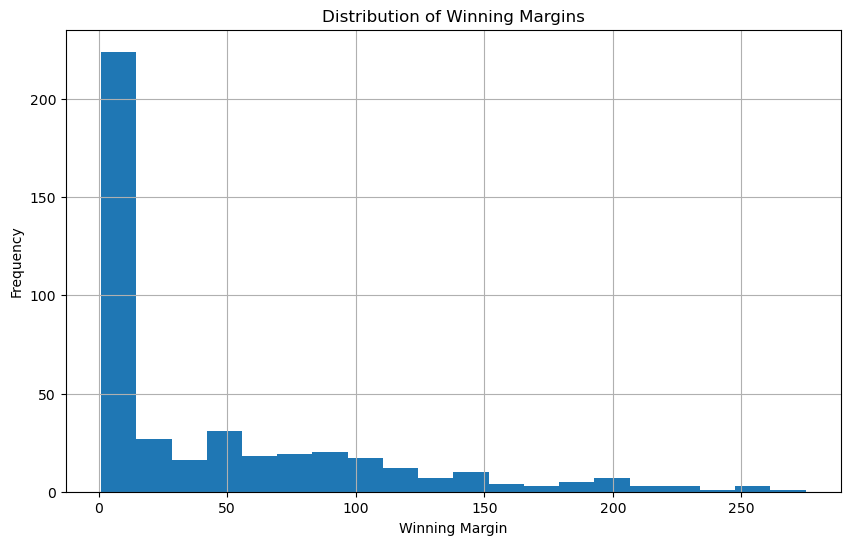

In [23]:
clean_df['margin'] = pd.to_numeric(clean_df['margin'], errors='coerce')

plt.figure(figsize=(10,6))
clean_df['margin'].hist(bins=20)

plt.title('Distribution of Winning Margins')
plt.xlabel('Winning Margin')
plt.ylabel('Frequency')

plt.show()

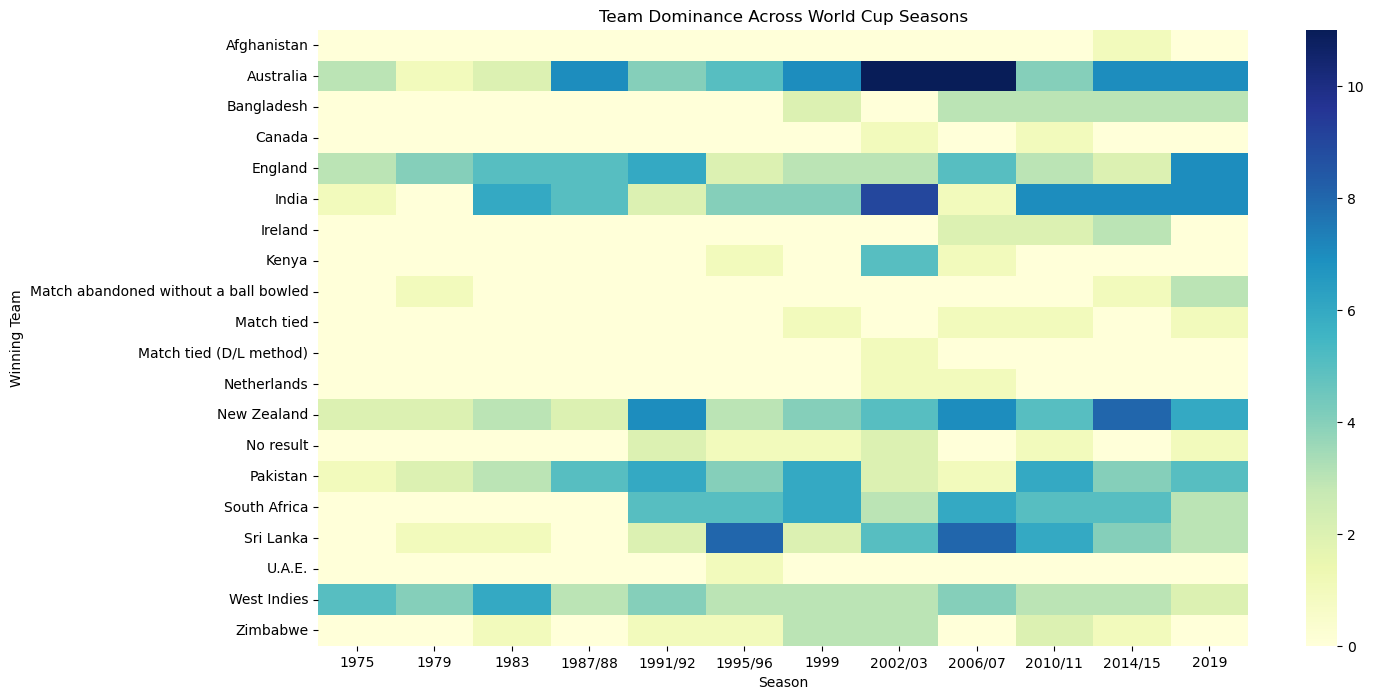

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = pd.crosstab(clean_df['winner'], clean_df['season'])

plt.figure(figsize=(15,8))
sns.heatmap(heatmap_data, cmap='YlGnBu')

plt.title('Team Dominance Across World Cup Seasons')
plt.xlabel('Season')
plt.ylabel('Winning Team')

plt.show()

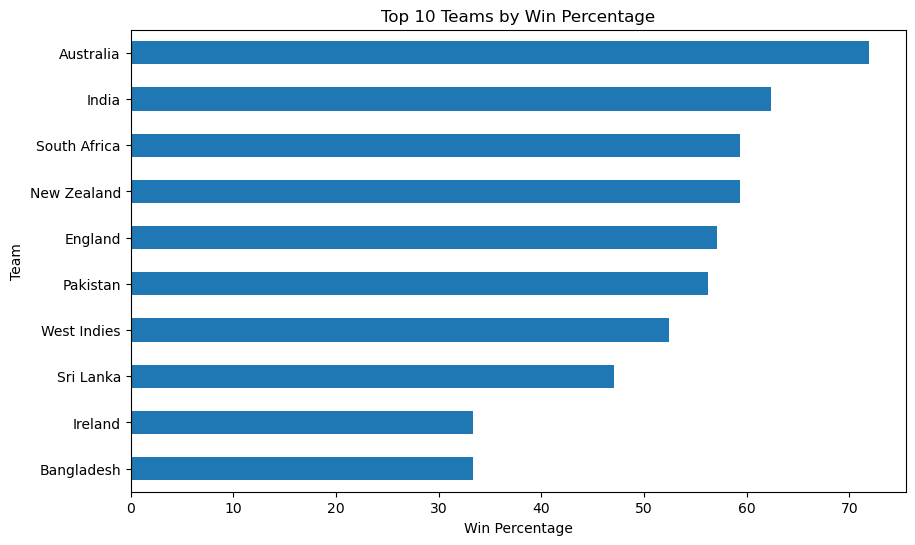

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

team1_matches = clean_df['team_1'].value_counts()
team2_matches = clean_df['team_2'].value_counts()

matches_played = team1_matches.add(team2_matches, fill_value=0)

wins = clean_df['winner'].value_counts()

win_rate = (wins / matches_played * 100).dropna()

top10 = win_rate.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top10.sort_values().plot(kind='barh')

plt.title('Top 10 Teams by Win Percentage')
plt.xlabel('Win Percentage')
plt.ylabel('Team')

plt.show()

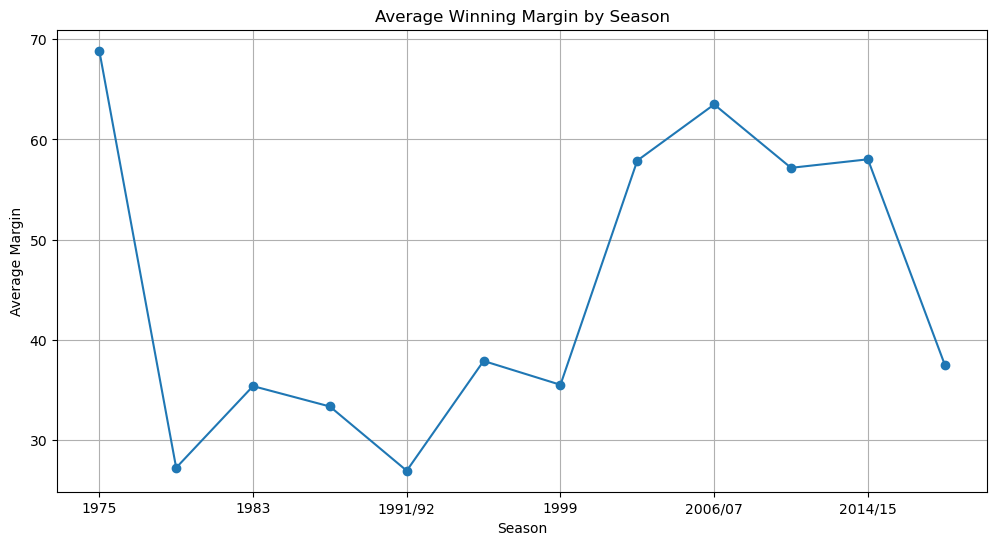

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

clean_df['margin'] = pd.to_numeric(clean_df['margin'], errors='coerce')

avg_margin = clean_df.groupby('season')['margin'].mean()

plt.figure(figsize=(12,6))
avg_margin.plot(marker='o')

plt.title('Average Winning Margin by Season')
plt.xlabel('Season')
plt.ylabel('Average Margin')

plt.grid(True)

plt.show()

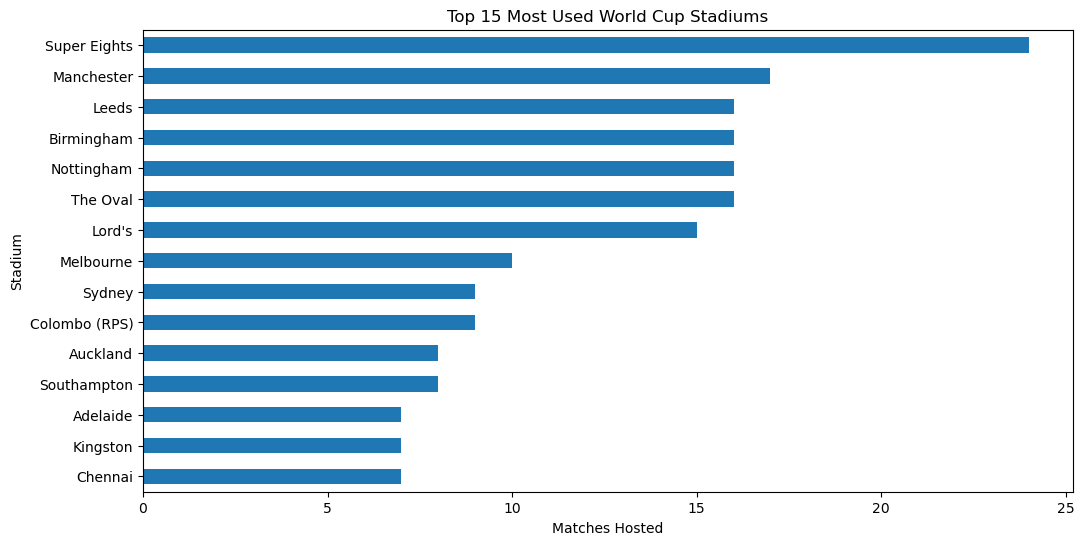

In [27]:
stadiums = clean_df['stadium'].value_counts().head(15)

plt.figure(figsize=(12,6))
stadiums.sort_values().plot(kind='barh')

plt.title('Top 15 Most Used World Cup Stadiums')
plt.xlabel('Matches Hosted')
plt.ylabel('Stadium')

plt.show()

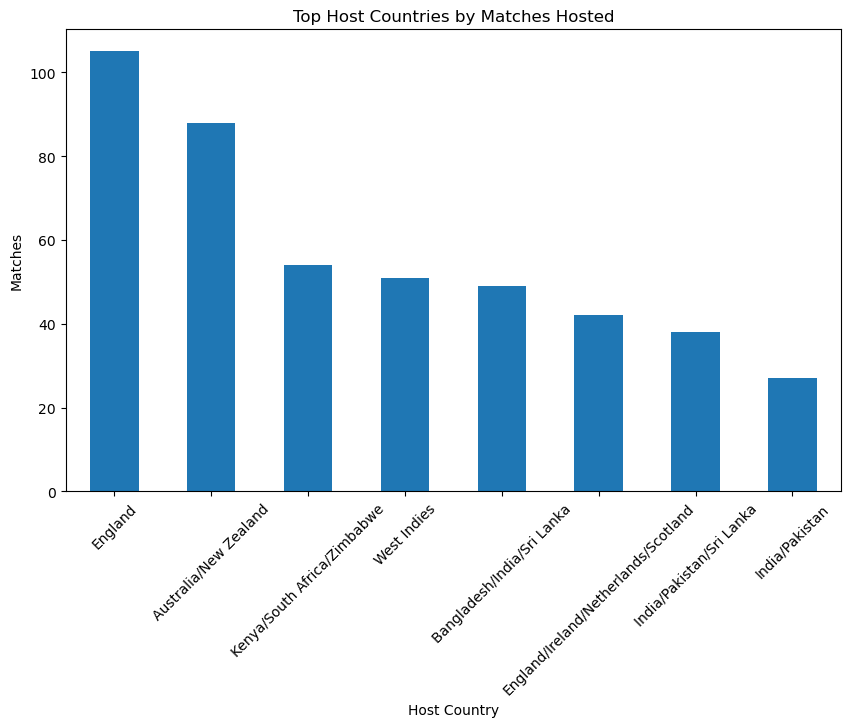

In [28]:
host_matches = clean_df['host'].value_counts().head(10)

plt.figure(figsize=(10,6))
host_matches.plot(kind='bar')

plt.title('Top Host Countries by Matches Hosted')
plt.xlabel('Host Country')
plt.ylabel('Matches')

plt.xticks(rotation=45)

plt.show()

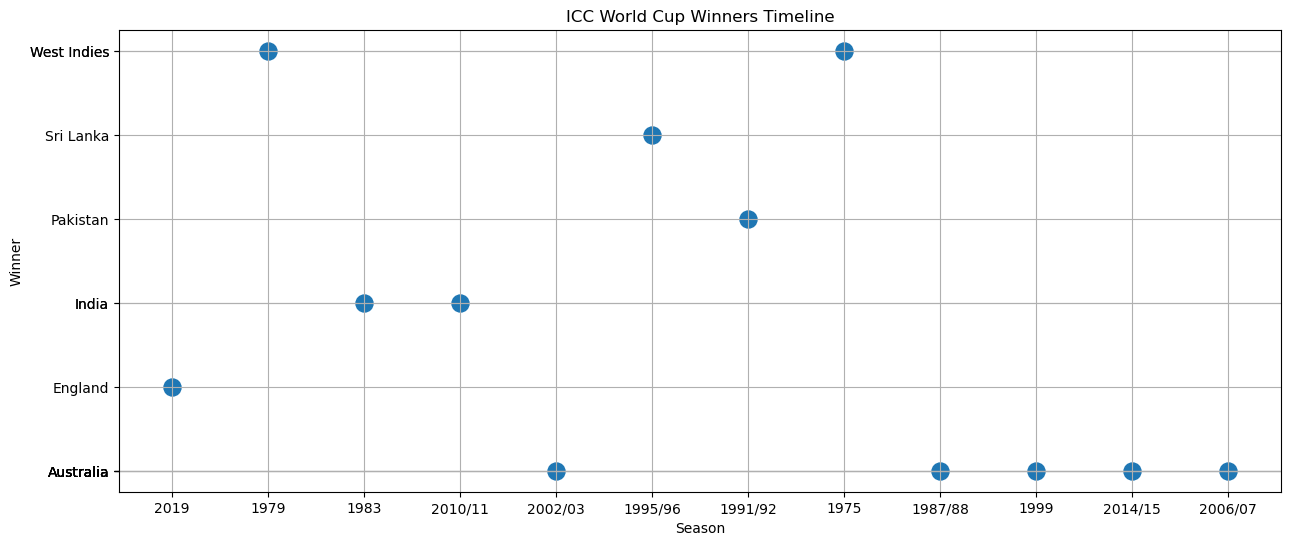

In [29]:
winners = clean_df[['season', 'season_winner']].drop_duplicates()

plt.figure(figsize=(15,6))

plt.scatter(
    winners['season'],
    winners['season_winner'].astype('category').cat.codes,
    s=150
)

plt.yticks(
    winners['season_winner'].astype('category').cat.codes,
    winners['season_winner']
)

plt.title('ICC World Cup Winners Timeline')
plt.xlabel('Season')
plt.ylabel('Winner')

plt.grid(True)

plt.show()

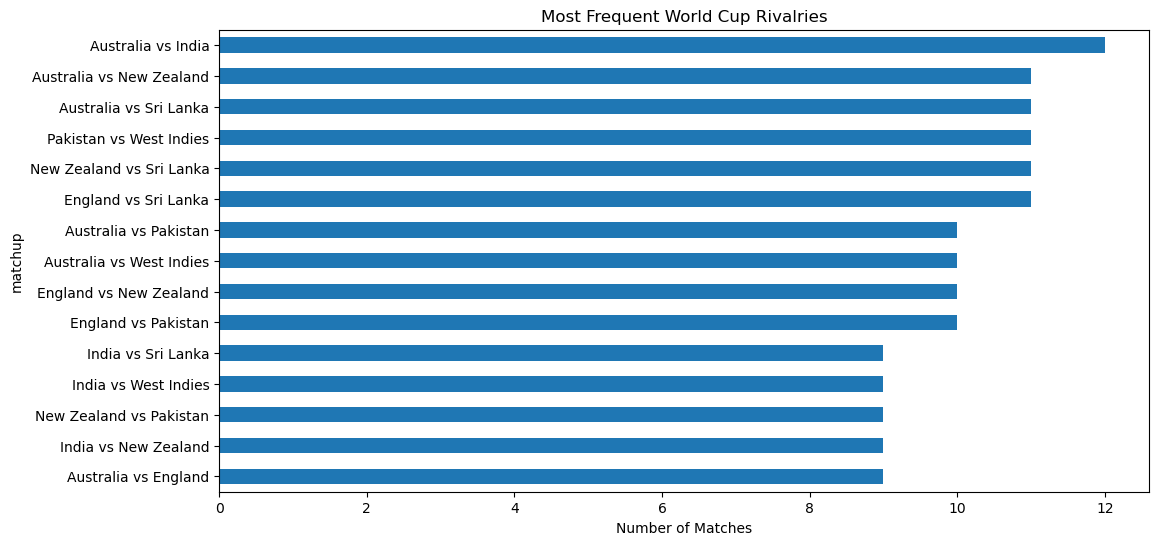

In [30]:
clean_df['matchup'] = clean_df.apply(
    lambda x: ' vs '.join(sorted([x['team_1'], x['team_2']])),
    axis=1
)

top_matchups = clean_df['matchup'].value_counts().head(15)

plt.figure(figsize=(12,6))
top_matchups.sort_values().plot(kind='barh')

plt.title('Most Frequent World Cup Rivalries')
plt.xlabel('Number of Matches')

plt.show()